# Topical Lectures, Controls 
## Drone control, part 2: system identification
Andreas Freise, Bas Swinkels 27.05.2026

Before we can start playing with control systems for our drone we need to first understand the drone itself a bit better. Each drone comes with roughly the same specification but the exact behaviour of each individual model is slightly different. For example, the left and right motors are not providing the exact same force when the same voltage is applied. Similarly they most likley won't have the same full range (V_min to V_max). 

We need to do some experiments to find the parameters that characterise our drone, so that we can compensate for such deviations in the actuation part of our control system.

First we learn how to do such experiments:
- from now on you need to call the ```drone``` command without the ```test``` paramater. Instead you have to specfify your full name, e.g. in my case :
 - ```MyName = "Andreas"```
 - ```drone = module.Drone(name=MyName)```. 
The name string is used to generate unique parameters for your drone. 
- The drone has two optional parameters: ```wind``` and ```flight_range```: ```wind``` is a Boolean variable, when ```True``` the drone experiences random external forces from airmotion. For the system identifcation we assume we are somewhere inside withour wind and can set ```wiind=False```. 
- We will use the ```flight_range``` extensively. It is an array of 4 values giving the lower left and upper right coordinates of the free range in which the drone can fly. This can be also used to `clmap' the drone in a jig for testing. For example, with ```flight_range=[0,0,0,0]``` the drone will not move sideways or up/down, but can still tilt. Similarly, using ```flight_range=[0,-500,0,500]``` linits the drone to up/down motion (tilt remains allowed).

In this notebook we will experiments in non-interactive way. You need to think ahead and plan your experiment and analyse the output afterwards. In practise this means you need to allocate an empty NumPy array to store the results, i.e. you have to decide in advance how mnay iterations you want to run. Let's try it out:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import module
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# This time we want inline plotting (non-interactive)
%matplotlib inline

# Don't forget to set the name string to your own name
MyName = "Andreas"

In [2]:
# First: just see how we can do some plotting without the interactve graph

drone = module.Drone(name=MyName, wind=False, flight_range=(-3, -3, 3, 3))

N = 3000 # number of iterations

# Allocating a NumPy array for our data, with N rows and 14 columns, of which 
# 12 column will be used to store drone output, and 2 columns for other data
results = np.zeros([N,14])

# The drone will return a SimpleNamespace with named attributes:
# t: time
# y: y (left-right) position in cm
# z: z (up-down) position in cm
# phi: angle of the drone in radians
# dy, dz, dphi: the respective velocities
# F: total force
# tau: torque
# F_left: force applied in left motor
# F_right: force applied in right motor
# target_idx: number of targets successfully reached (in the right order)

# We will use the results array to store two further values:
# the voltage we send to the left and right rotor.

V_left = 0.5
V_right = 0.5

for i in range(N):
    # each iteration we can set the voltage of the motors
    drone.set_V(V_left, V_right)
    # the update functions performs one iteration of 1/60 s duration and returns the state of the drone
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right] # append voltages just to record everything


Now we can plot what happened in our experiment:

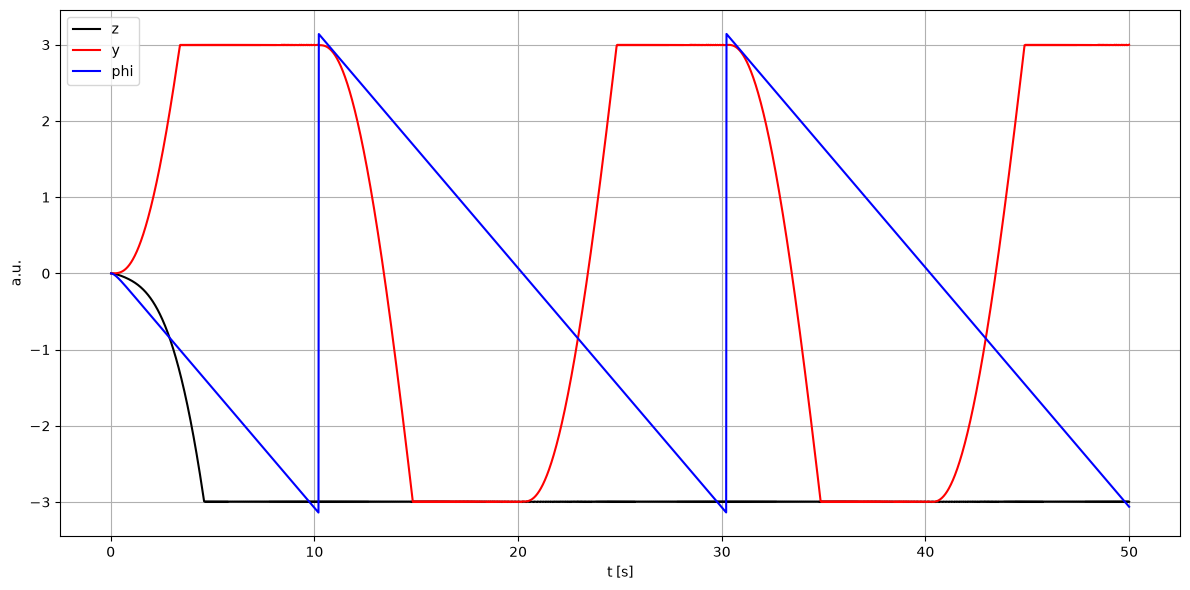

In [3]:
# plotting the y,z position and tilt of the drone as a function of time 
t = results[:,0]
y = results[:,1]
z = results[:,2]
phi = results[:,3]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t,z, 'k', label="z")
plt.plot(t,y, 'r', label="y")
plt.plot(t,phi, 'b', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

We see that without any corrections our drone rolls and falls. 

Next, we should try to stabilise the tilt by finding the right volatges for the left and right rotors to balance the forces. We can find the right voltages, for eample, by ramping the voltage of one rotor during the experiment and then check when the acceleration of the tilt (phi'') becomes zero.

In [4]:
# Use drag-free dynamics for the calibration sweeps; drag would make
# ddphi=0 happen at a wrong point (where torque balances drag, not zero).
drone = module.Drone(name=MyName, wind=False, flight_range=[0,0,0,0],
                     drag_t=0, drag_r=0)
N = 400
results = np.zeros([N,14])

# Base voltage at 0.5 (mid-throttle, well inside [0, 1]); the original
# value of 1.0 sits right at the actuator clip and breaks the sweep.
V_left  = 0.5
V_right = 0.5

# The new model is more sensitive in angle than the old one, so the
# offset sweep is narrower than before.
max_offset = 0.001
V_left_offset =  -1 * max_offset
V_left_offset =  -0.00275 -1 * max_offset

for i in range(N):
    # ramping the left voltage
    V_left_offset += 2.0 * max_offset / N
    drone.set_V(V_left + V_left_offset, V_right)
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12] = V_left_offset # this time we store the offset only


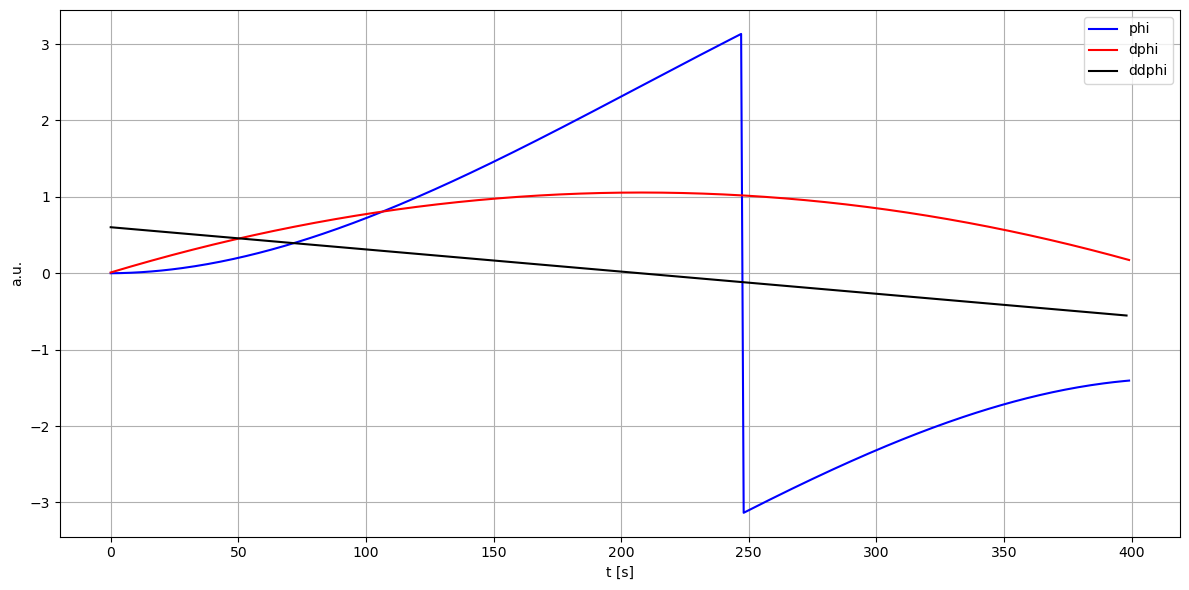

In [5]:
t = results[:,0]
y = results[:,1]
z = results[:,2]
phi = results[:,3] # angle
dphi = results[:,6] # angular velocity
ddphi = np.diff(dphi)/np.diff(t) # angular acceleration phi'' (derivative of phi')
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(phi, 'b', label="phi")
plt.plot(dphi, 'r', label="dphi")
plt.plot(ddphi, 'k', label="ddphi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

The best way to find a specifc value in an array with Python is the using the ```argmin``` function from NumPy. In this case we want to know when ```ddphi``` is zero, and then get the voltage offset at which this ocured:

In [6]:
idx = np.argmin(np.abs(ddphi-0))
print(f"ddphi = {ddphi[idx]}")

ddphi = 0.0013337356669485038


In [7]:
V_left_offset = results[idx,12]
print(f"V_left_offset  = {V_left_offset}")

V_left_offset  = -0.0027100000000000422


(Before continuing, you might want to re-run the above to find a more accurate value for this offset. You can do that by decreasing 'max_offset' and starting with 'V_left_offset = (the result from above) -1 * max_offset')

Now we can run the drone using the new-found offset and see if we have a more stable (in tilt) drone:

In [8]:
# Verification run with realistic drag. With the offset compensated
# the drone should no longer roll, but V_left = V_right = 0.5 is below
# the (yet to be identified) hover voltage so it will still drift down.
drone = module.Drone(name=MyName, wind=False, flight_range=(-3, -3, 3, 3))
N = 3000
results = np.zeros([N,14])
V_left = 0.5 + V_left_offset
V_right = 0.5

for i in range(N):
    drone.set_V(V_left, V_right)
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]


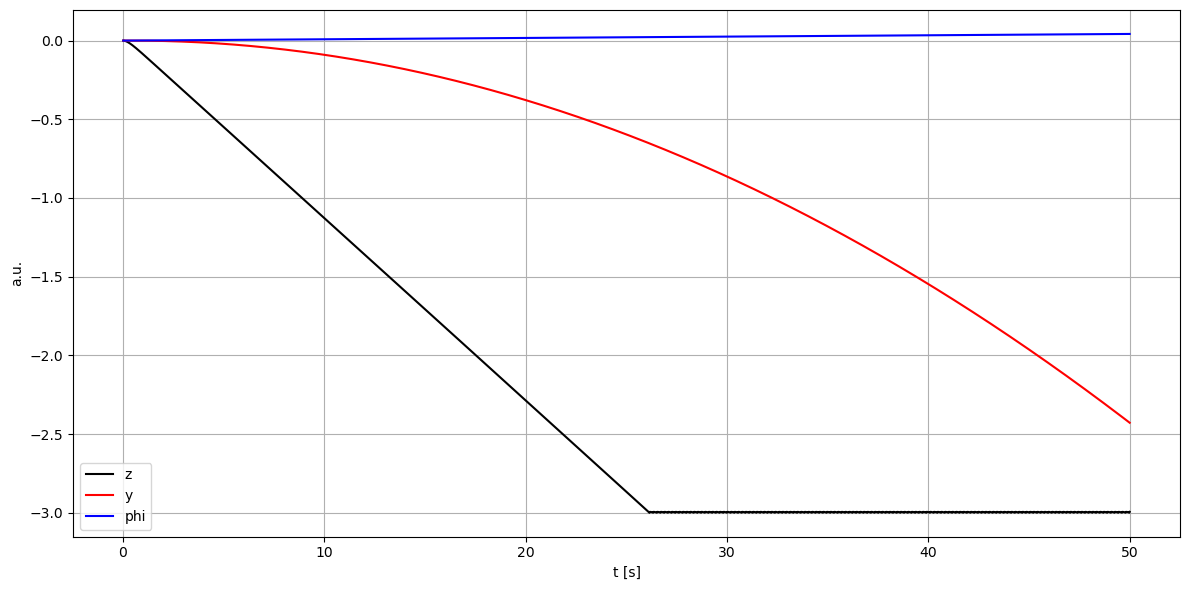

In [9]:
t = results[:,0]
y = results[:,1]
z = results[:,2]
phi = results[:,3]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t,z, 'k', label="z")
plt.plot(t,y, 'r', label="y")
plt.plot(t,phi, 'b', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

OK, this should be a bit better. Maybe we could use a more accurate value to balance it even better. It does not need to be perfect as we will use a control loop later.

We suggest as the next experiments:
1) find the voltages for the drone to hover
2) find the maximum and minimum voltages that can be safely applied (before one of the rotors stops reacting)

The first of these test could follow the same technique as before, e.g. ramp the voltages together (while using the offset from before to balance the rotors) and find the moment when z'' becomes zero.

In [10]:
drone = module.Drone(name=MyName, wind=False, flight_range=(0, -3, 0, 3),
                     drag_t=0, drag_r=0)
N = 200
results = np.zeros([N,14])

# Ramp the common voltage from 0.50 to 0.60 -- the new V_hover sits in
# this band (around 0.52-0.53 for the default drone).
V_left  = 0.50
V_right = 0.50
dV = 0.10 / N

for i in range(N):
    V_left  += dV
    V_right += dV
    drone.set_V(V_left + V_left_offset, V_right)
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]


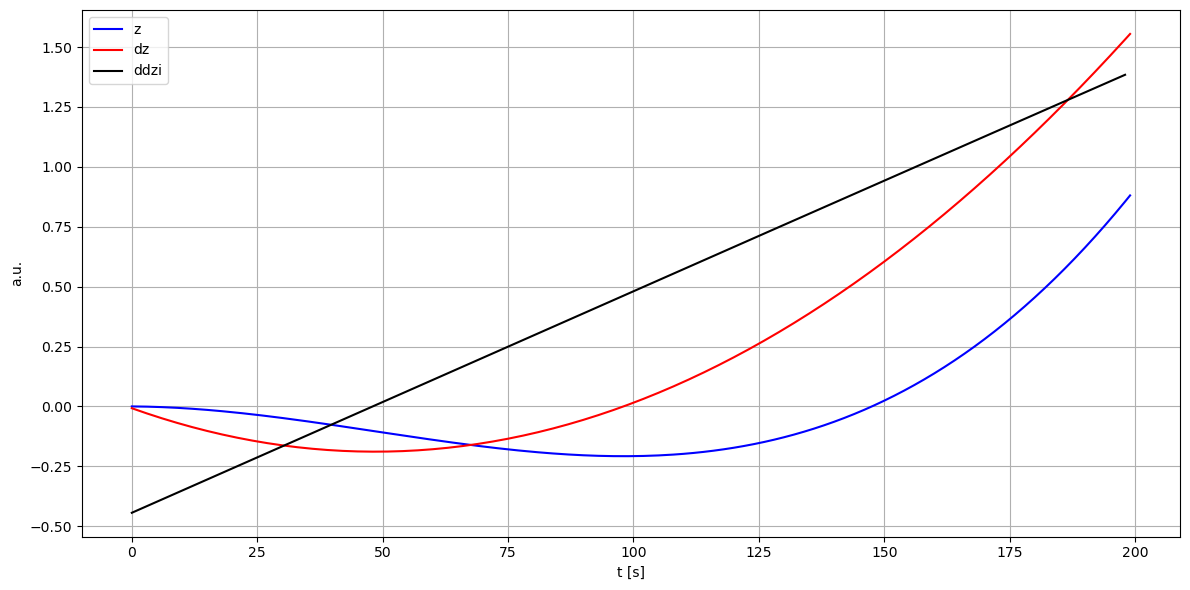

In [11]:
t = results[:,0]
z = results[:,2]
dz = results[:,5]
ddz = np.diff(dz)/np.diff(t)
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(z, 'b', label="z")
plt.plot(dz, 'r', label="dz")
plt.plot(ddz, 'k', label="ddzi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

In [12]:
idx = np.argmin(np.abs(ddz-0))
print(ddz[idx])
print(results[idx,12], results[idx,13])

-7.771499011155456e-05
0.5244999999999973 0.5244999999999973


In [13]:
V_hover  = results[idx,12]

In [14]:
# Verification with the calibrated V_hover. With drag on, the drone
# should hover essentially in place (residual offset error is dissipated
# by drag, not accumulated as in a frictionless model).
drone = module.Drone(name=MyName, wind=False, flight_range=(-3, -3, 3, 3))
N = 600
results = np.zeros([N,14])

V_left = V_hover
V_right = V_hover

for i in range(N):
    drone.set_V(V_left+V_left_offset, V_right)
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]


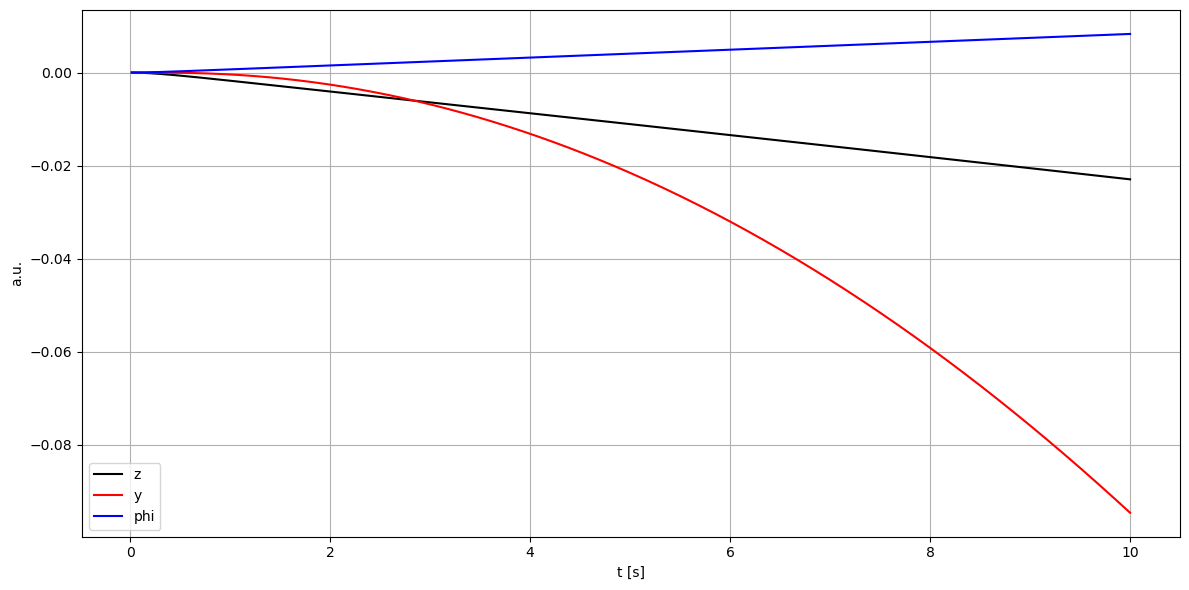

In [15]:
t = results[:,0]
y = results[:,1]
z = results[:,2]
phi = results[:,3]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(t,z, 'k', label="z")
plt.plot(t,y, 'r', label="y")
plt.plot(t,phi, 'b', label="phi")
ax.set_xlabel("t [s]")
ax.set_ylabel("a.u.")
plt.grid()
plt.legend()
plt.tight_layout()

Finally we want to check for clipping, i.e. find out what are the maximum and minimum voltages for each motor. We can use this information later to limit the feedback of our control to a safe range.

In [16]:
# Sweep the common-mode voltage from below V_min to above V_max so we
# can see both clipping limits in one experiment. flight_range fixes
# the drone in place so the trace is purely about motor response.
drone = module.Drone(name=MyName, wind=False, flight_range=[0,0,0,0],
                     drag_t=0, drag_r=0)
N = 1400
results = np.zeros([N,14])

V_left  = -0.2
V_right = -0.2
dV = 1.4 / N

for i in range(N):
    V_left  += dV
    V_right += dV
    drone.set_V(V_left + V_left_offset, V_right)
    state = drone.update()
    results[i,0:12] = module.state_to_array(state)
    results[i,12:14] = [V_left,V_right]


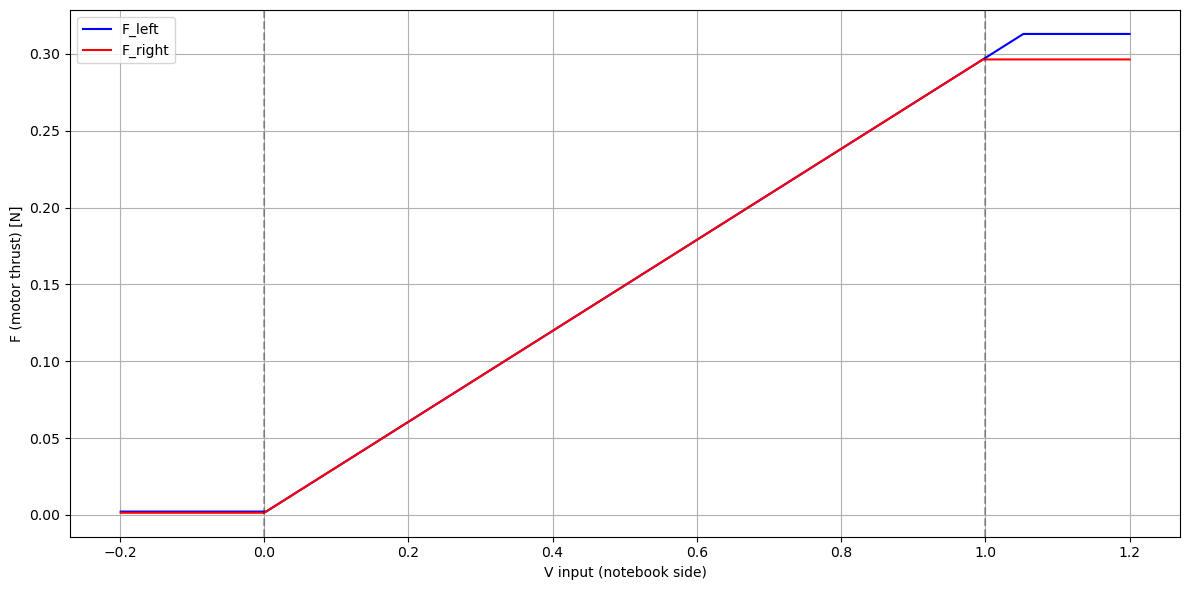

In [17]:
# F_left and F_right come from state.F_left / state.F_right which are
# the actual motor forces after the drone has applied its internal
# clipping and motor-amplitude scaling.
V_in    = results[:, 12]
F_left  = results[:, 9]
F_right = results[:, 10]
fig, ax = plt.subplots(1, figsize=(12,6))
plt.plot(V_in, F_left,  'b', label="F_left")
plt.plot(V_in, F_right, 'r', label="F_right")
ax.axvline(0.0, color='k', alpha=0.3, ls='--')
ax.axvline(1.0, color='k', alpha=0.3, ls='--')
ax.set_xlabel("V input (notebook side)")
ax.set_ylabel("F (motor thrust) [N]")
plt.grid()
plt.legend()
plt.tight_layout()


In [18]:
V_max = 1.0
V_min = 0    # motors are single-direction (PWM 0..max)


Now we have identified the parameters for our specifc drone. Let's print then so that we can copy and paste the values as variables into the next notebooks for the drone controls.

In [19]:
print(f"V_left_offset = {V_left_offset}")
print(f"V_hover = {V_hover}")
print(f"V_max = {V_max}")
print(f"V_min = {V_min}")

V_left_offset = -0.0027100000000000422
V_hover = 0.5244999999999973
V_max = 1.0
V_min = 0
